# Titanic Survival Analysis
## A Python Data Analytics Project
### By Gayathri

## 1. Data Loading
The Titanic dataset contains 891 passengers and 12 columns including survival status, demographic and ticket information.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Exploration
Checking the shape, columns and missing values in the dataset.

In [5]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Findings:
- Dataset has 891 passengers and 12 columns
- Age has 177 missing values
- Cabin has 687 missing values (77% missing!)
- Embarked has 2 missing values

## 3. Data Cleaning
Handling missing values and dropping unusable columns.

In [6]:
# Fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

# Fill Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


### Findings:
- Age filled with median value (28)
- Cabin dropped due to 77% missing data
- Embarked filled with most common port (S)

## 4. Data Visualization

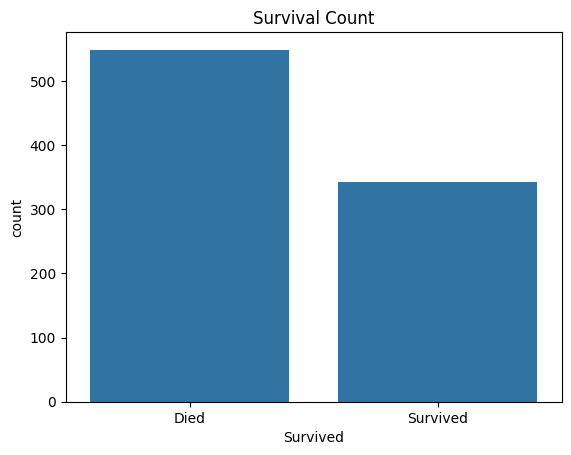

In [8]:
# Chart 1 - Survival Count
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.savefig('survival_count.png')
plt.show()

### Finding:
Only 38% of passengers survived the Titanic disaster. 
More than 500 passengers died while less than 350 survived.

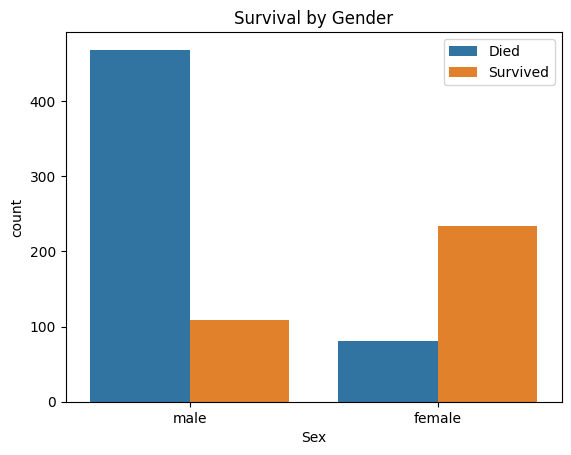

In [9]:
# Chart 2 - Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.savefig('survival_by_gender.png')
plt.show()

### Finding:
Females had a significantly higher survival rate compared to males, 
due to the "Women and children first" evacuation policy followed during the disaster.

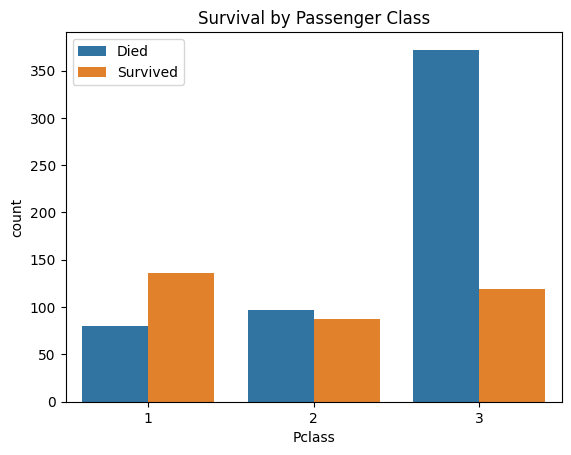

In [10]:
# Chart 3 - Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.savefig('survival_by_class.png')
plt.show()

### Finding:
First class passengers had the highest survival rate while third class 
had the highest death rate, due to cabin location proximity to lifeboats 
and evacuation priority given to higher class passengers.

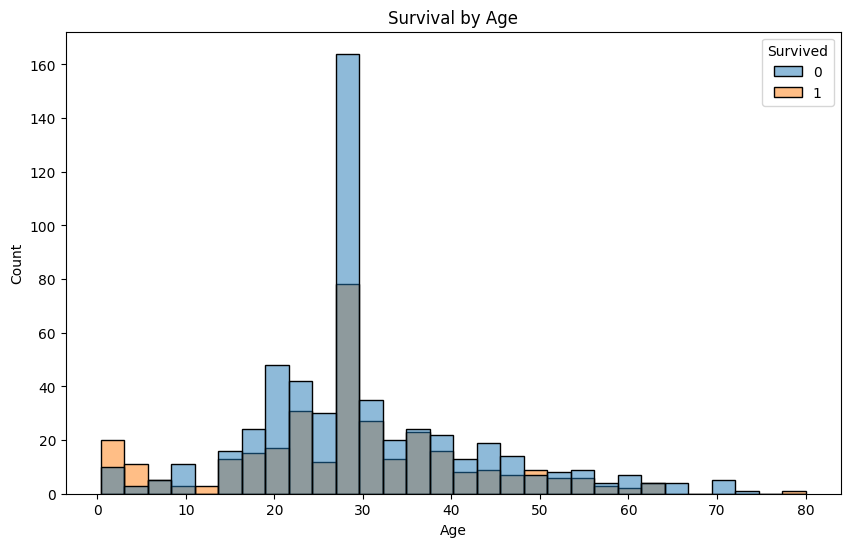

In [11]:
# Chart 4 - Survival by Age
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.title('Survival by Age')
plt.savefig('survival_by_age.png')
plt.show()

### Finding:
Age was not a strong survival factor compared to gender and class. 
However young children had slightly better survival chances. 
The average age of survivors (28) and those who died (30) were very similar.

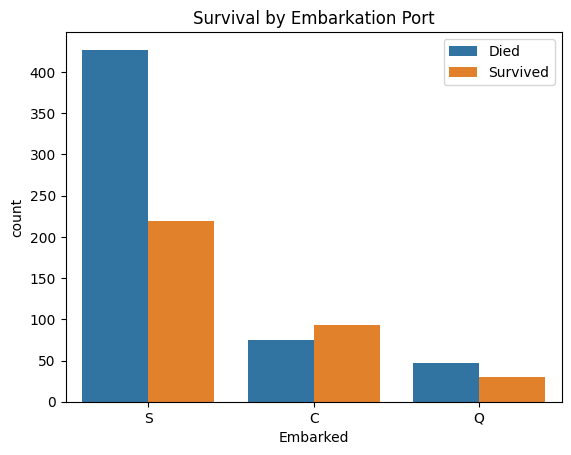

In [12]:
# Chart 5 - Survival by Embarkation Port
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarkation Port')
plt.legend(['Died', 'Survived'])
plt.savefig('survival_by_embarked.png')
plt.show()

### Finding:
Cherbourg (C) passengers had the highest survival rate at 55%, 
followed by Queenstown (Q) at 39% and Southampton (S) at 34%. 
Cherbourg had more 1st class passengers which explains the higher survival rate.

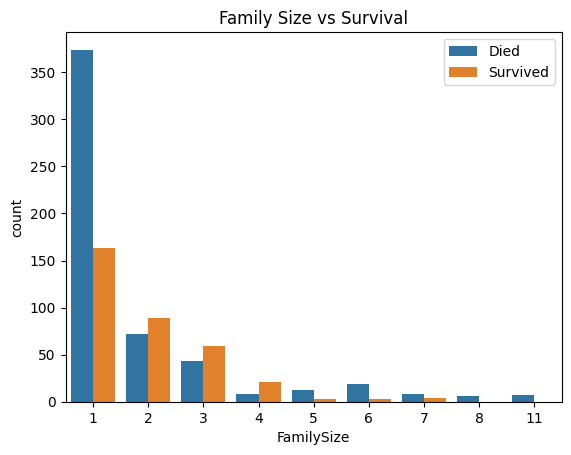

In [13]:
# Chart 6 - Family Size vs Survival
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title('Family Size vs Survival')
plt.legend(['Died', 'Survived'])
plt.savefig('survival_by_familysize.png')
plt.show()

### Finding:
Passengers travelling in small families of 2-4 had higher survival rates 
compared to solo travellers and large families. Solo travellers had the 
highest death rate while very large families (5+) also struggled to evacuate together.

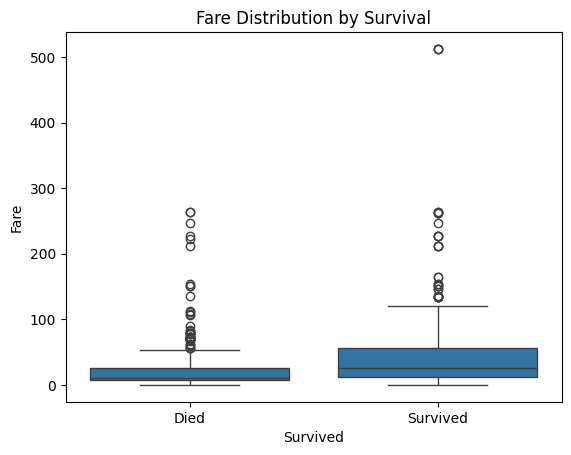

In [14]:
# Chart 7 - Fare Distribution by Survival
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.savefig('fare_by_survival.png')
plt.show()

### Finding:
Passengers travelling in small families of 2-4 had higher survival rates 
compared to solo travellers and large families. Solo travellers had the 
highest death rate while very large families (5+) also struggled to evacuate together.

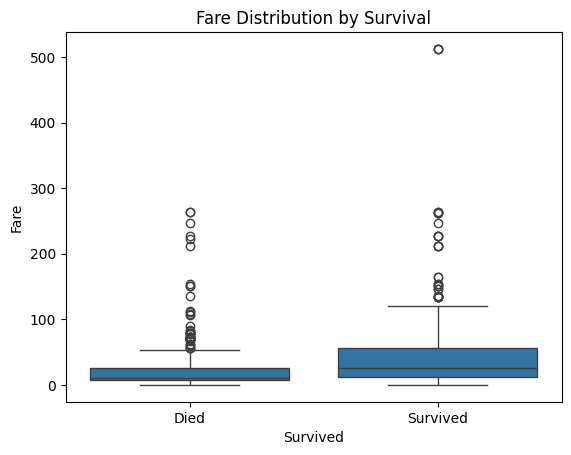

In [15]:
# Chart 7 - Fare Distribution by Survival
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.savefig('fare_by_survival.png')
plt.show()

### Finding:
Survivors paid significantly higher fares on average compared to those who died. 
Higher fare indicates higher class which meant better cabin location 
and evacuation priority. One survivor paid as high as £512!

## 5. Predictive Model - Random Forest
Building a machine learning model to predict survival.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Convert categorical to numbers
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Features and target
features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked']
X = df[features]
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy:', round(accuracy * 100, 2), '%')

Model Accuracy: 83.24 %


### Finding:
A Random Forest model with 100 decision trees was built using features like 
gender, class, age, fare, family size and embarkation port. 
The model achieved 83.24% accuracy on the test data, meaning it correctly 
predicts survival for 83 out of every 100 passengers.

### Finding:
A Random Forest model with 100 decision trees was built using features like 
gender, class, age, fare, family size and embarkation port. 
The model achieved 83.24% accuracy on the test data, meaning it correctly 
predicts survival for 83 out of every 100 passengers.

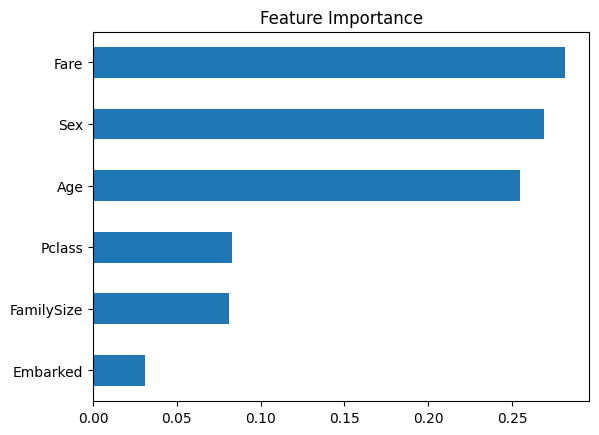

In [17]:
# Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=features)
feature_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.savefig('feature_importance.png')
plt.show()

### Finding:
Fare was the most important feature followed by Sex and Age. 
Embarked was the least important feature. This confirms that 
wealth, gender and age were the strongest predictors of survival.

## 7. Conclusion

Key findings from the Titanic Survival Analysis:

1. Only 38% of passengers survived the disaster
2. Females had significantly higher survival rates than males
3. 1st class passengers survived more than 3rd class passengers
4. Cherbourg passengers had the highest survival rate at 55%
5. Small families of 2-4 had better survival chances than solo travellers
6. Higher fare passengers had better survival chances
7. Random Forest model achieved 83.24% accuracy in predicting survival